In [1]:
import pandas as pd
import numpy as np

from sklearn.metrics.pairwise import cosine_similarity

import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
ratings = pd.read_csv(
    r".\u.data\u.data",
    sep="\t",
    names=["user_id","movie_id","rating","timestamp"]
)

In [9]:
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [10]:
print("Number of Ratings :", len(ratings))
print("Number of Users   :", ratings["user_id"].nunique())
print("Number of Movies  :", ratings["movie_id"].nunique())

Number of Ratings : 100000
Number of Users   : 943
Number of Movies  : 1682


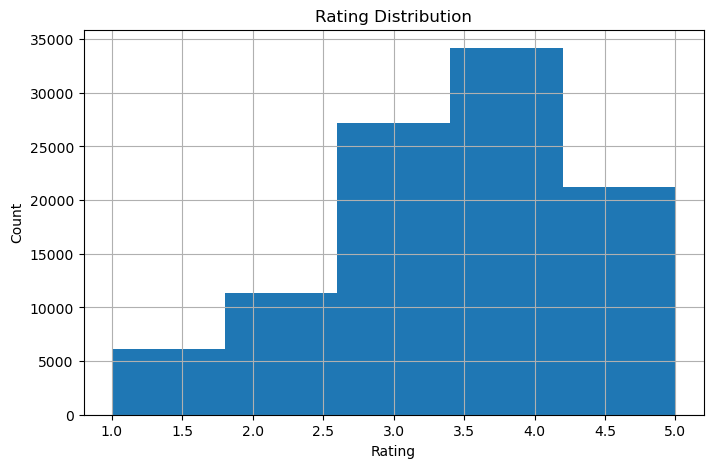

In [11]:
plt.figure(figsize=(8,5))

ratings["rating"].hist(bins=5)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")

plt.savefig("Rating_Distribution.png")

plt.show()

In [12]:
user_movie_matrix = ratings.pivot_table(
    index="user_id",
    columns="movie_id",
    values="rating"
)

user_movie_matrix = user_movie_matrix.fillna(0)

user_movie_matrix.head()

movie_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,4.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [13]:
user_similarity = cosine_similarity(
    user_movie_matrix
)

user_similarity_df = pd.DataFrame(
    user_similarity,
    index=user_movie_matrix.index,
    columns=user_movie_matrix.index
)

user_similarity_df.head()

user_id,1,2,3,4,5,6,7,8,9,10,...,934,935,936,937,938,939,940,941,942,943
user_id,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.166931,0.047460,0.064358,0.378475,0.430239,0.440367,0.319072,0.078138,0.376544,...,0.369527,0.119482,0.274876,0.189705,0.197326,0.118095,0.314072,0.148617,0.179508,0.398175
2,0.166931,1.000000,0.110591,0.178121,0.072979,0.245843,0.107328,0.103344,0.161048,0.159862,...,0.156986,0.307942,0.358789,0.424046,0.319889,0.228583,0.226790,0.161485,0.172268,0.105798
3,0.047460,0.110591,1.000000,0.344151,0.021245,0.072415,0.066137,0.083060,0.061040,0.065151,...,0.031875,0.042753,0.163829,0.069038,0.124245,0.026271,0.161890,0.101243,0.133416,0.026556
4,0.064358,0.178121,0.344151,1.000000,0.031804,0.068044,0.091230,0.188060,0.101284,0.060859,...,0.052107,0.036784,0.133115,0.193471,0.146058,0.030138,0.196858,0.152041,0.170086,0.058752
5,0.378475,0.072979,0.021245,0.031804,1.000000,0.237286,0.373600,0.248930,0.056847,0.201427,...,0.338794,0.080580,0.094924,0.079779,0.148607,0.071459,0.239955,0.139595,0.152497,0.313941


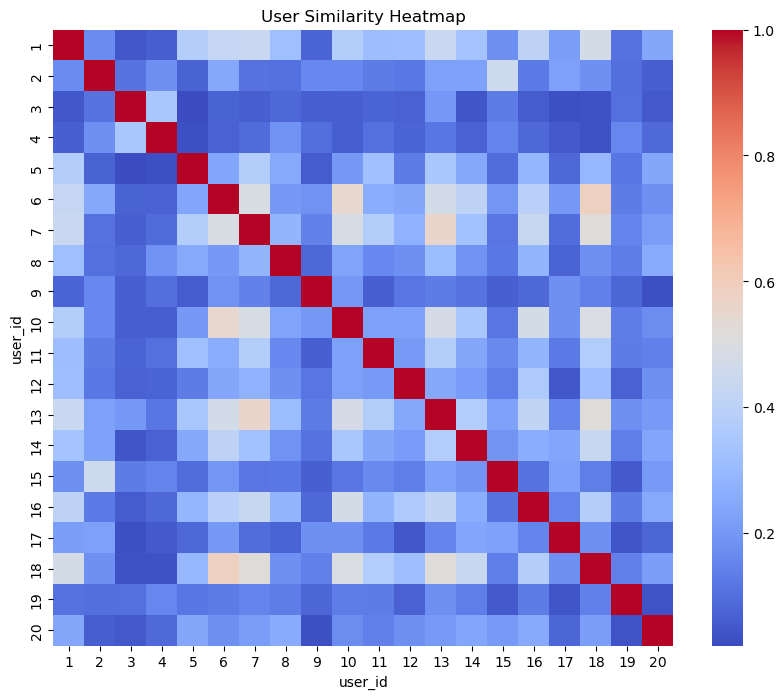

In [14]:
plt.figure(figsize=(10,8))

sns.heatmap(
    user_similarity_df.iloc[:20,:20],
    cmap="coolwarm"
)

plt.title("User Similarity Heatmap")

plt.savefig("User_Similarity_Heatmap.png")

plt.show()

In [26]:
def recommend_movies(user_id, n=10):

    similar_users = user_similarity_df[user_id] \
                        .sort_values(ascending=False)

    similar_users = similar_users.iloc[1:11]

    recommended_movies = {}

    for sim_user in similar_users.index:

        sim_score = similar_users[sim_user]

        movies_rated = user_movie_matrix.loc[sim_user]

        for movie_id, rating in movies_rated.items():

            if rating > 3:

                if movie_id not in recommended_movies:

                    recommended_movies[movie_id] = 0

                recommended_movies[movie_id] += rating * sim_score

    recommendations = sorted(
        recommended_movies.items(),
        key=lambda x: x[1],
        reverse=True
    )

    return recommendations[:n]

In [27]:
recommendations = recommend_movies(1)

recommendations

[(50, np.float64(26.897931833137097)),
 (174, np.float64(26.371981906419013)),
 (172, np.float64(25.83036719845175)),
 (98, np.float64(25.302873785397797)),
 (56, np.float64(24.764397810358407)),
 (181, np.float64(24.180748444364266)),
 (183, np.float64(24.1727573039926)),
 (176, np.float64(23.699116468018694)),
 (234, np.float64(23.107061698606113)),
 (96, np.float64(22.98611968759484))]

In [17]:
recommendation_df = pd.DataFrame(
    recommendations,
    columns=["Movie ID","Recommendation Score"]
)

recommendation_df

,Movie ID,Recommendation Score
0,50,26.897932
1,174,26.371982
2,172,25.830367
3,98,25.302874
4,56,24.764398
5,181,24.180748
6,183,24.172757
7,176,23.699116
8,234,23.107062
9,96,22.986120


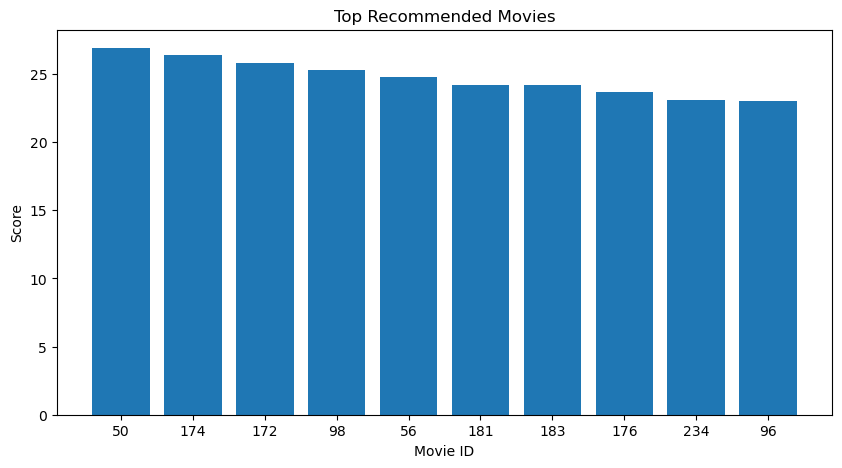

In [18]:
plt.figure(figsize=(10,5))

plt.bar(
    recommendation_df["Movie ID"].astype(str),
    recommendation_df["Recommendation Score"]
)

plt.title("Top Recommended Movies")
plt.xlabel("Movie ID")
plt.ylabel("Score")

plt.savefig("Top_Recommendations.png")

plt.show()

In [29]:
from sklearn.metrics import mean_squared_error

predicted = ratings["rating"].mean()

rmse = np.sqrt(
    mean_squared_error(
        ratings["rating"],
        [predicted]*len(ratings)
    )
)

print("RMSE :", rmse)

RMSE : 1.1256679707622492


In [31]:
print("\nRECOMMENDATIONS AND FUTURE WORK\n")

recommendations = [
    "1. Exclude Previously Rated Movies - Improve recommendation quality by ensuring that movies already rated by a user are not recommended again.",
    
    "2. Use Advanced Similarity Measures - Replace cosine similarity with Pearson Correlation or Adjusted Cosine Similarity to better capture user preferences.",
    
    "3. Incorporate Movie Metadata - Include movie titles, genres, release years, and other attributes to provide more informative recommendations.",
    
    "4. Implement Item-Based Collaborative Filtering - Compare item-based and user-based recommendation approaches to identify the most effective method.",
    
    "5. Apply Matrix Factorization Techniques - Use algorithms such as Singular Value Decomposition (SVD) to improve recommendation accuracy and handle sparse datasets.",
    
    "6. Use Additional Evaluation Metrics - Evaluate performance using MAE, Precision@K, Recall@K, F1-Score, and NDCG alongside RMSE.",
    
    "7. Address the Cold-Start Problem - Introduce popularity-based and content-based recommendation methods for new users and movies.",
    
    "8. Develop an Interactive Application - Build a Streamlit or Gradio web application to allow users to receive recommendations through a user-friendly interface.",
    
    "9. Test Scalability - Evaluate system performance on larger datasets and optimize similarity computations for real-world deployment.",
    
    "10. Build a Hybrid Recommendation System - Combine collaborative filtering, content-based filtering, and popularity-based methods to improve recommendation quality and robustness."
]

for item in recommendations:
    print(item)

print("\nThese enhancements can significantly improve recommendation accuracy, user experience, and the overall effectiveness of the recommendation system.")


RECOMMENDATIONS AND FUTURE WORK

1. Exclude Previously Rated Movies - Improve recommendation quality by ensuring that movies already rated by a user are not recommended again.
2. Use Advanced Similarity Measures - Replace cosine similarity with Pearson Correlation or Adjusted Cosine Similarity to better capture user preferences.
3. Incorporate Movie Metadata - Include movie titles, genres, release years, and other attributes to provide more informative recommendations.
4. Implement Item-Based Collaborative Filtering - Compare item-based and user-based recommendation approaches to identify the most effective method.
5. Apply Matrix Factorization Techniques - Use algorithms such as Singular Value Decomposition (SVD) to improve recommendation accuracy and handle sparse datasets.
6. Use Additional Evaluation Metrics - Evaluate performance using MAE, Precision@K, Recall@K, F1-Score, and NDCG alongside RMSE.
7. Address the Cold-Start Problem - Introduce popularity-based and content-based re

In [30]:
print("\nCONCLUSION\n")

print("""
This project successfully developed a User-Based Collaborative Filtering
Movie Recommendation System using the MovieLens dataset. The dataset was
explored and transformed into a user-movie interaction matrix, which enabled
the calculation of user similarities using cosine similarity.

Based on these similarities, personalized movie recommendations were generated
for users. Various visualizations, including rating distribution plots,
user similarity heatmaps, and recommendation charts, were created to better
understand user behavior and recommendation patterns.

The model demonstrates the effectiveness of collaborative filtering techniques
in providing personalized recommendations without requiring detailed movie
content information. The evaluation using RMSE provided a basic assessment
of the model's predictive performance.

Overall, this project provides a strong foundation for building more advanced
recommendation systems and highlights the practical application of machine
learning techniques in real-world recommendation scenarios.
""")


CONCLUSION


This project successfully developed a User-Based Collaborative Filtering
Movie Recommendation System using the MovieLens dataset. The dataset was
explored and transformed into a user-movie interaction matrix, which enabled
the calculation of user similarities using cosine similarity.

Based on these similarities, personalized movie recommendations were generated
for users. Various visualizations, including rating distribution plots,
user similarity heatmaps, and recommendation charts, were created to better
understand user behavior and recommendation patterns.

The model demonstrates the effectiveness of collaborative filtering techniques
in providing personalized recommendations without requiring detailed movie
content information. The evaluation using RMSE provided a basic assessment
of the model's predictive performance.

Overall, this project provides a strong foundation for building more advanced
recommendation systems and highlights the practical application of mach